# Notatki

# Import wymaganych pakietów

In [1]:
import wurtzite as wzt
import numpy as np
import matplotlib.pyplot as plt
from utils_1st import displace_love2
import scipy.integrate
import dataclasses
import copy
from scipy.integrate import quad_vec

# Stałe

In [2]:
NU = 0.35
BETA_ONES = np.eye(3)  # Jedynka 3x3
DIMS = 3  # Liczba wymiarow (x, y, z)
DIS_TOLERANCE = 1e-1

# Funkcje

### Funkcje pomocnicze

Nasza definicja $\arctan$.

In [3]:
def atan2(y, x):
    if np.isclose(y, 0.0) and np.isclose(x, 0.0):
        # zmiana wzgledem standardu
        return 0.0
    else:
        return np.arctan2(y, x)

Poniższa funkcja zamienia współrzędne kartezjańskie na biegunowe $(r, \theta)$.

In [4]:
def to_polar(vector):
    r = np.hypot(vector[0], vector[1])
    theta = atan2(vector[1], vector[0])
    return r, theta

Poniższa funkcja tworzy sekwencję macierzy jedynek $\mathbf{1}$.

In [5]:
def broadcast_eye(n, nrepeats):
    return np.array([np.eye(n)]*nrepeats)

Poniższa funkcja przekształca wektor burgersa $(b_x, b_y, b_z)$ na składową krawędziową $b_e$ oraz śrubową $b_z$.

In [6]:
def get_be_bz(cell, burgers_vector):
    bv_angstrom = cell.to_cartesian_indices(burgers_vector)
    be = np.sqrt(bv_angstrom[0] ** 2 + bv_angstrom[1] ** 2)
    bz = bv_angstrom[2]
    return be, bz

Oblicza całkę z funkcji `func` ($R^n \rightarrow R^m$). Całka liczona jest po linii prostej między `a` i `b` (`= limits`).

In [7]:
def calculate_integral_vec(func, limits, n=3):
    if np.isclose(np.linalg.norm(limits[0]-limits[1]), 0.0):
        return np.zeros(n)

    a, b = limits
    direction = b-a
    direction_T = direction.T

    def integrand(t: float) -> np.ndarray:
        l = a + t*direction
        b = func(l).squeeze()
        return b @ direction_T

    result, abserror = quad_vec(integrand, 0.0, 1.0)
    result = result.squeeze()
    return result

Poniższa klasa pomocnicza zbiera wszystkie informacje na temat dyslokacji w konfiguracji, t.j. ich stan (położenie, wektor burgersa) oraz ostatnią macierz obrotu.

Niezbędne do poprawnego wyznaczenia bet.

In [8]:
@dataclasses.dataclass
class DislocationsState:
    d1: wzt.model.DislocationDef
    d2: wzt.model.DislocationDef
    d1_rt: np.ndarray
    d2_rt: np.ndarray

    @property
    def tuple(self):
        return self.d1, self.d2, self.d1_rt, self.d2_rt

    def copy(self, **kwargs):
        return DislocationsState(**{**self.__dict__, **kwargs})

### Obroty

Poniższa funkcja tensor obrotu sztywnego na podstawie wskaźników Millera.

In [9]:
def get_rigid_rotation_tensor_miller(burgers_vector, plane, cell: wzt.model.UnitCellDef):

    normalize = wzt.dislocations._normalize
    
    s = cell.to_cartesian_indices(np.asarray(burgers_vector))
    s = normalize(s)
    m = np.transpose(cell.miller_to_cartesian).dot(plane)
    m = normalize(m)
    mxs = normalize(np.cross(m, s))
    mxsxm = normalize(np.cross(mxs, m))
    return np.array([
        [mxsxm[0], mxsxm[1], mxsxm[2]],
        [mxs[0],   mxs[1],   mxs[2]  ],
        [m[0],     m[1],     m[2]    ],
    ])

In [10]:
class MillerIndices:

    def __init__(self, crystal, d2_global):
        cell = crystal.cell
        position = np.asarray(d2_global.position)
        burgers_vector = np.asarray(d2_global.b)
        plane = np.asarray(d2_global.plane)
        position = position.reshape(-1, 1)
        self.rt = get_rigid_rotation_tensor_miller(
            burgers_vector=burgers_vector,
            plane=plane,
            cell=cell
        )
        self.rt_inv = np.transpose(self.rt)
        self.cd = self.rt.dot(position).squeeze()  # (3, )
        
    def preprocess(self, x):
        x = self.rt.dot(x.T).T
        x = x - self.cd.reshape(1, -1)
        return x

    def postprocess(self, u):
        return self.rt_inv.dot(u.T).T

    def postprocess_points(self, x):
        x = x + self.cd.reshape(1, -1)
        return self.rt_inv.dot(x.T).T

Poniższa funkcja zwraca macierz obrotu dla punktu `p` wynikającą z dyslokacji `dis_a`. 

Zakładamy, że punkt `p` jest wyrażony we współrzędnych kartezjańskich w układzie współrzędnych zaczepionym w dyslokacji `dis_a`. Położenie dyslokacji `dis_a` może być zarówno wyrażona w układzie globalnym jak i lokalnym (`dis_a.position` nie ma znaczenia).



In [11]:
def get_rotation_matrix(l0, dis_a, p, debug=False):
    be, bz = get_be_bz(l0.cell, dis_a.b)
    dis_b_local_pos = np.asarray(p).reshape(1, -1)
    BETA_ONES = np.eye(3)
    betas = beta(dis_b_local_pos, be=be, bz=bz)
    F_inv = (BETA_ONES - betas)
    F = np.linalg.inv(F_inv[0, :2, :2])

    ba = np.asarray([1.0, 0.0])

    ba_rotated = F.dot(ba)
    ba = ba_rotated / np.linalg.norm(ba_rotated)
    ba_orto = np.array([[0, -1],
                        [1, 0]]).dot(ba)
    ba_z = np.asarray([0, 0, 1])
    
    rotmatrix = np.eye(3)
    rotmatrix[:2, 0] = ba
    rotmatrix[:2, 1] = ba_orto
    return rotmatrix

Poniższa funkcja zwraca obrócony wektor burgersa `bv` dyslokacji położonej w punkcie `p`. Wektor burgersa jest obrócony zgodne z betami wynikającymi z dysloakcji `dis_a`. 

Funkcja ta zachowuje oryginalną długość wektora burgersa `bv`.

**UWAGA: skladowa srubowa jest zerowana** (nie ma znaczenia dla eksperymentów w tym notatniku).

De facto, zwracana jest para: nowy wektor burgersa, macierz obrotu.

In [12]:
def rotate_dislocation(crystal, reference_dislocation, p, bv):
    dis_b_rt = get_rotation_matrix(crystal, reference_dislocation, p)
    dis_b_b = dis_b_rt[:2, :2].dot(bv[:2]).squeeze()
    orig_norm = np.linalg.norm(bv)
    dis_b_b = dis_b_b/np.linalg.norm(dis_b_b)*orig_norm
    dis_b_b = np.asarray(dis_b_b.tolist() + [0])
    return dis_b_b, dis_b_rt

### Funkcja $\beta$

Oblicza funkcję $\beta$ dla wybranego punktu `x`. Zmienna `be` to składowa krawędziowa wektora burgersa, `bz` to składowa śrubowa.

In [13]:
def beta(x, be, bz):
    x = np.asarray(x)
    if len(x.shape) == 1:
        x = x[np.newaxis, ...]

    x1 = x[..., 0]  # (n_atoms, )
    x2 = x[..., 1]
    x1_2 = x1 ** 2
    x2_2 = x2 ** 2
    r2 = x1_2 + x2_2

    a = be / (4 * np.pi * (1.0 - NU) * r2 * r2)
    # du / dx1
    b11 = (-1) * a * x2 * (
                (3.0 - 2.0 * NU) * x1_2 + (1.0 - 2.0 * NU) * x2_2)  # (natoms, )
    b21 = (-1) * a * x1 * ((1.0 - 2.0 * NU) * x1_2 + (3.0 - 2.0 * NU) * x2_2)
    b31 = (-1) * bz / (2.0 * np.pi) * x2 / r2
    # du / dx2
    b12 = a * x1 * ((3.0 - 2.0 * NU) * x1_2 + (1.0 - 2.0 * NU) * x2_2)
    b22 = a * x2 * ((1.0 + 2.0 * NU) * x1_2 - (1.0 - 2.0 * NU) * x2_2)
    b32 = bz / (2.0 * np.pi) * x1 / r2
    result = np.repeat(BETA_ONES.copy()[np.newaxis, ...], len(x1), axis=0)
    result[:, 0, 0] = b11
    result[:, 1, 0] = b21
    result[:, 2, 0] = b31
    result[:, 0, 1] = b12
    result[:, 1, 1] = b22
    result[:, 2, 1] = b32

    # Atoms in the center of dislocation core: just equal 1
    # (1-beta will be zero)
    core_center_atoms = r2 < 1e-15  # (natoms, )
    result[core_center_atoms, :, :] = BETA_ONES
    return result  # (natoms, 3, 3)

Poniższa funkcja zwraca bety dla podanej kolekcji punktów `points`.

Bety są odpowiednio obracane wg podanej macierzy obrotu `rotation_matrix` t.j. $\beta_n = \mathbf{R}^T_n\beta(x-x_n)\mathbf{R}_n$.

Uwaga: poniższe obliczneia są zwektoryzowane na wszystkie punkty `points`.

In [14]:
def get_betas(crystal, d, points, rotation_matrix, dis_tolerance=DIS_TOLERANCE):
    if rotation_matrix is None:
        return np.zeros((points.shape[0], 2, 2))
        
    be, bz = get_be_bz(crystal.cell, d.b)
    # Przenieść do układu zaczepionego w dyslokacji (istotne np. dla d1). 
    points = np.asarray(points)-np.asarray(d.position)
    points = rotation_matrix.dot(points.T).T
    betas = beta(points, be=be, bz=bz)[:, :2, :2]
    rm = rotation_matrix[:2, :2].reshape(1, 2, 2)
    
    # KLUCZOWA INSTRUKCJA
    betas = rm.transpose((0, 2, 1)) @ betas @ rm

    # clean-up betas
    # Make sure that any point that is close to the dislocation core is zeroed.
    # Otherwise, we may get very large values (due to division by x**2+y**2 in
    # the beta function).
    # NOTE: point is already in the d local coordinate system
    # (see -d.position above)
    
    # Odleglosci miedzy punktem i dyslokacja
    p_d_distance = np.linalg.norm(points[..., :2], axis=1)
    # Wyzeruj bety dla punktów dostatecznie blisko d (w zakresie promienia dis_tolerance).
    near_points = np.squeeze(np.isclose(p_d_distance, 0.0, atol=dis_tolerance))
    betas[near_points, :] = 0.0
    return betas

Poniższa funkcja wyznacza wartość $\beta^{\Sigma}$. Obecnie uwzględnia tylko dwie dyslokacje.

In [15]:
def get_beta_sigma(crystal, d_state):
    d1 = d_state.d1
    d2 = d_state.d2
    d1_rt = d_state.d1_rt
    d2_rt = d_state.d2_rt

    betas_1 = get_betas(crystal, d1, l.reshape(-1, 3), d1_rt)
    betas_2 = get_betas(crystal, d2, l.reshape(-1, 3), d2_rt)
    return betas_1 + betas_2

### $\mathbf{u} = \int_{x_o}^{\hat{x}}F_{\Sigma_{N+1}}\beta_{N+1}d\hat{l}$

In [16]:
def get_u(x_o, x_dash, crystal, d_state):
    d1 = d_state.d1
    d2 = d_state.d2
    d1_rt = d_state.d1_rt
    d2_rt = d_state.d2_rt

    def f_int(l):
        betas_1 = get_betas(crystal, d1, l.reshape(-1, 3), d1_rt)
        betas_2 = get_betas(crystal, d2, l.reshape(-1, 3), d2_rt)

        betas = betas_1+betas_2
        betas = betas[0]
        F_inv = (np.eye(2) - betas)
        F = np.linalg.inv(F_inv)
        result = np.zeros((3, 3))
        result[:2, :2] = F @ betas_1
        return result

    return calculate_integral_vec(f_int, (x_o, x_dash))

### Algorytm: wyznaczanie pola przemieszczeń

Notacja:
- `d1`, `d2`: dyslokacja pierwsza i druga
- `rt`: macierz obrotu
- `p`: punkt (atom)
- `bv`: wektor burgersa
- `_global`: obiekt o współrzędnych w układzie globalnym
- `_local`: obiekt o współrzędnych w układzie lokalnym zaczepionym w `d2`.

Uproszczenia:
- zakłada sie, że `d2` ma wektor burgersa [1, 0, 0],

**Główna procedura**

# Eksperymenty

### Konfiguracja pierwotna

Tworzymy strukturę przechowującą siatkę krystalograficzną.

Text(0.5, 1.0, 'Initial configuration')

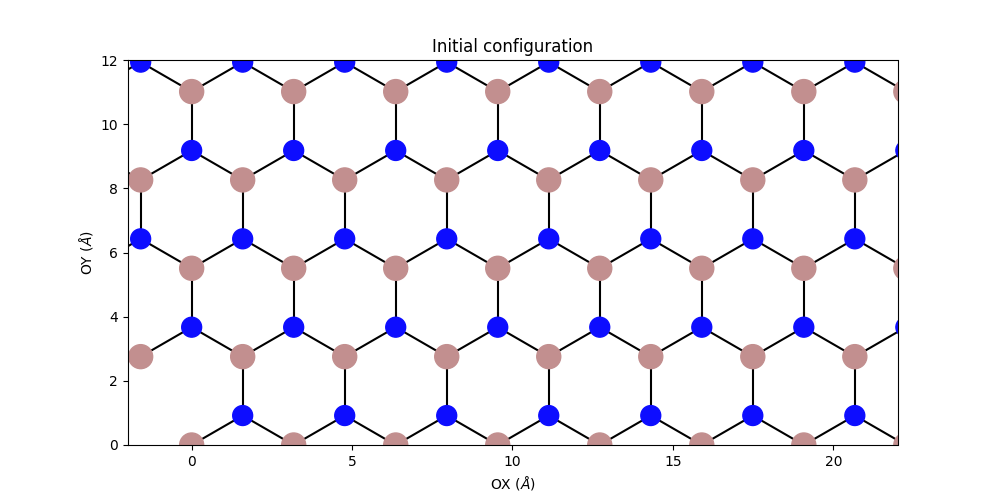

In [17]:
l0 = wzt.generate.create_lattice(
    dimensions=(10, 10, 1),  # (nx, ny, nz)
    cell="B4_GaN",
)

%matplotlib widget
fig, ax = wzt.visualization.plot_atoms_2d(l0, xlim=(-2, 22), ylim=(0, 12), figsize=(10, 5))
ax.set_title("Initial configuration")

### Pierwsza dyslokacja

Text(0.5, 1.0, 'Current configuration (1st dislocation)')

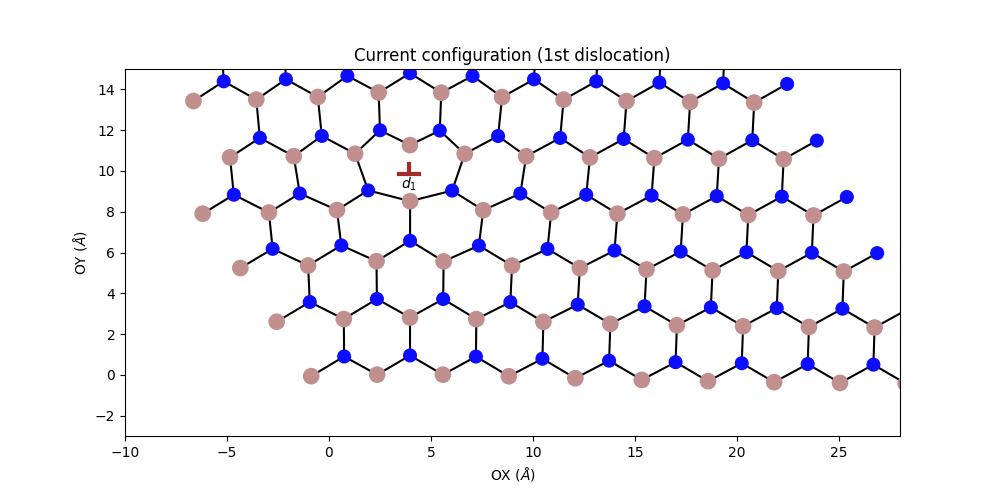

In [18]:
d1 = wzt.model.DislocationDef(
    # Wektor burgersa
    b=[1, 0, 0],
    # Położenie rdzenia dyslokacji
    position=[3.920+0.0*l0.cell.dimensions[0], 3.5+2*l0.cell.dimensions[1], 7.5],
    # Płaszczyzna
    plane=(0, 0, 1),
    # Etykieta (tylko do prezentacji)
    label="$d_1$",
    # Kolor (tylko do prezentacji)
    color="brown"
)

# Użyj metody takiej jak w pracy Cholewinskiego
# Pelna implementacja tej metody w utils_1st.
# u0 -- gotowe pole przemiesczeń
u0, all_us = displace_love2(
    crystal=l0,
    position=d1.position,
    burgers_vector=d1.b,
    plane=d1.plane,
    bv_fraction=1.0,
)


# Przesuń atomy
l1 = l0.translate(u0)
# Zaktualizuj wiązania
l1 = wzt.generate.update_bonds(l1)

# Wyswietl nowa siatke
%matplotlib widget
fig, ax = wzt.visualization.plot_atoms_2d(l1, xlim=(-10, 28), ylim=(-3, 15), figsize=(10, 5))
# Wyswietl teownik
wzt.visualization.display_tee_2d(ax, d1, scale=0.5)
ax.set_title("Current configuration (1st dislocation)")

In [19]:
np.max(np.linalg.norm(u0, axis=-1))

np.float64(1.5485336876408926)

Wnioski z eksperymentów:
- błędem było użycie @betas_1 zamiast @betas_2.

Zamienilem 0.5 RADIUS_FACTOR na 1/2 b

Atom: 199

<Axes: title={'center': 'Dislocation field (u), OXY'}, xlabel='OX ($\\AA$)', ylabel='OY ($\\AA$)'>

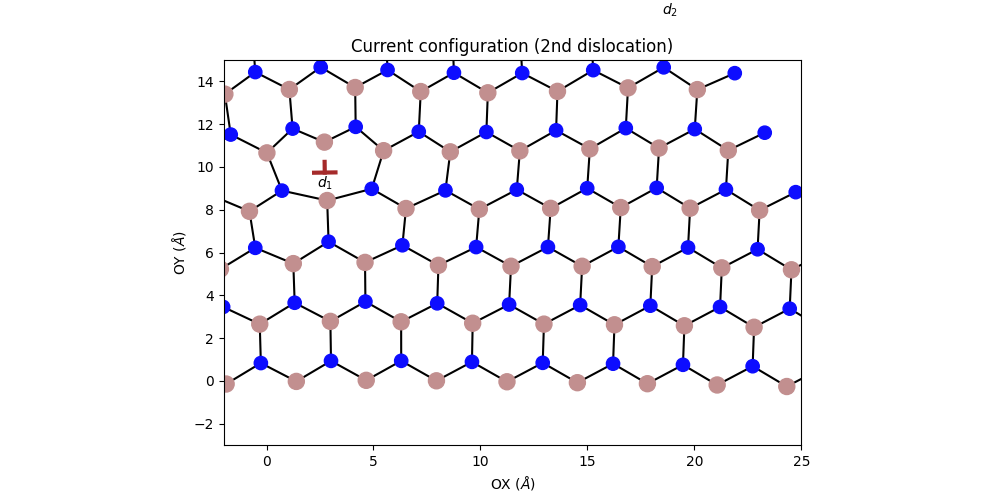

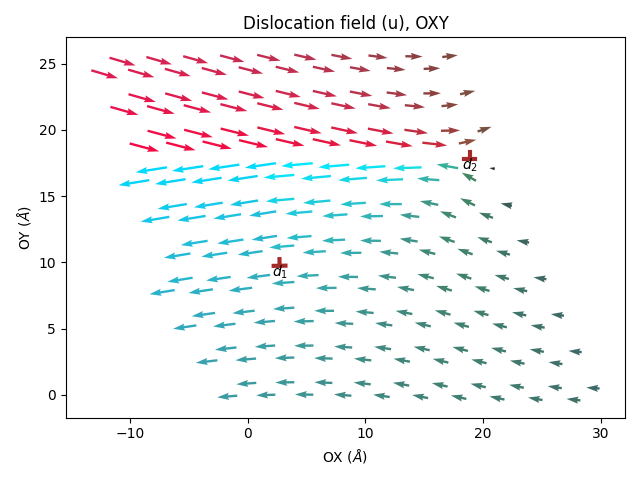

In [20]:
def line_integral(F, a, b, n=1000):
    """
    Liczy przybliżoną wartość całki krzywoliniowej funkcji wektorowej F
    po odcinku prostym między punktami a i b:
    
        ∫₀¹ F(a + t(b - a)) · (b - a) dt

    Parameters:
    - F: funkcja wektorowa F(r), r to wektor 3D (np. numpy array)
    - a, b: końce ścieżki, numpy array (3D)
    - n: liczba przedziałów (większa = większa dokładność)

    Returns:
    - Całkowita wartość całki krzywoliniowej (float)
    """
    a = np.asarray(a).reshape(-1, 1)
    b = np.asarray(b).reshape(-1, 1)
    delta = b - a
    dt = 1.0 / n
    integral = 0.0
    # print(f"a: {a.squeeze()}, b: {b.squeeze()}, b-a: {np.linalg.norm(b.squeeze()-a.squeeze())}")

    for i in range(n):
        t = i * dt
        r_t = a + t * delta
        F_val = F(r_t)
        # print(f"F = {F_val}")
        dot = np.dot(F_val, delta)
        integral += dot * dt

    return integral.squeeze()


def get_u(x_o, x_dash, crystal, d_state, debug=False):
    d1 = d_state.d1
    d2 = d_state.d2
    d1_rt = d_state.d1_rt
    d2_rt = d_state.d2_rt

    def f_int(l):
        betas_1 = get_betas(crystal, d1, l.reshape(-1, 3), d1_rt, dis_tolerance=0.2)[0]
        betas_2 = get_betas(crystal, d2, l.reshape(-1, 3), d2_rt, dis_tolerance=0.2)[0]
        
        betas = betas_1 + betas_2
        F_inv = (np.eye(2) - betas)

        # if debug: a
        #     print(f"l: {l}")
        #     print(f"betas: {betas}")
        
        if not np.isclose(np.linalg.det(F_inv), 0):
            F = np.linalg.inv(F_inv)
            result = np.zeros((3, 3))
            # result[:2, :2] = betas
           
            
            result[:2, :2] = np.dot(F, betas_2) 
            return result
        else:
            return np.zeros(3)

    direction = np.sign(x_dash.squeeze()[1] - np.asarray(d2.position)[1])

    offset = direction*np.asarray([0.0, 10.0, 0.0])
    x_o1 = np.asarray(x_o).squeeze() + offset
    x_o2 = np.asarray(x_dash).squeeze() + offset
    
    i0 = line_integral(f_int, a=x_o, b=x_o1)
    i1 = line_integral(f_int, a=x_o1, b=x_o2)
    i2 = line_integral(f_int, a=x_o2, b=x_dash)
    return i0 + i1 + i2
    # Determine whether the integration line should go up or down
    # return line_integral(f_int, a=x_o, b=x_dash)


def displace_all(crystal, d1, d2):    
    n_atoms = crystal.coordinates.shape[0]
    be, bz = get_be_bz(crystal.cell, d2.b)
    x_o = np.asarray([0.5*be, 0.0, 0.0])
    
    # Obróć dyslokację d2 zgodnie z betami wyznaczonymi przez d1.
    new_d2_bv, d2_rt = rotate_dislocation(
        crystal,
        reference_dislocation=d1,
        # przenies d2 do ukladu wspolrzednych d1
        p=np.asarray(d2.position)-np.asarray(d1.position),
        bv=d2.b
    )

    d2_global = dataclasses.replace(d2, b=new_d2_bv)
    d2_local = dataclasses.replace(d2_global, b=np.asarray([1.0, 0, 0]), position=[0.0, 0, 0])

    # Wyznaczamy macierz obrotu Miller
    miller = MillerIndices(crystal=crystal, d2_global=d2_global)

    # Przenosimy wszystko do układu współrzędnych drugiej dyslokacji.
    atoms_local = miller.preprocess(crystal.coordinates.copy())  # (n atoms, 3)
    d1_pos_local = miller.preprocess(np.array(d1.position).reshape(1, 3))  # (1, 3)
    d1_local = dataclasses.replace(d1, position=d1_pos_local)

    # Ustalmy docelowy obrót oraz położenie d1.
    d1_local_current = d1_local
    d1_bv, d1_rt = rotate_dislocation(
        crystal, 
        reference_dislocation=d1,
        bv=d1.b,
        p=d1_pos_local
    )
    d1_local = dataclasses.replace(d1_local, b=d1_bv)
    d_state = DislocationsState(
        d1=d1_local_current,
        d2=d2_local,
        d1_rt=d1_rt,
        d2_rt=d2_rt
    )
    u_d1 = get_u(x_o, d1_local.position, crystal, d_state)
    # u_d1 = np.zeros(3)
    d1_local_current = dataclasses.replace(d1_local_current, position=d1_pos_local+u_d1, b=d1_bv)
    
    d_state = d_state.copy(d1=d1_local_current)
    
    u_atoms = []
    for i, c in enumerate(atoms_local):
        print(f"Atom: {i}", end="\r")
        if True: # i == 45:
            u = get_u(x_o, c, crystal, d_state)# , debug=(i == 45))
            # print(f"{i}, u magnitude: {np.linalg.norm(u)}")
            u_atoms.append(u)
    u_atoms = np.stack(u_atoms)
    
    # postprocess
    u_atoms = miller.postprocess(u_atoms)
    d1 = dataclasses.replace(d1_local_current, position=np.squeeze(d1.position + miller.postprocess(u_d1)))
    return d1, u_atoms


d2 = wzt.model.DislocationDef(
    # Wektor burgersa
    b=[1, 0, 0],
    position= np.asarray(d1.position)+np.array([4.7*l0.cell.dimensions[0], 2.5*l0.cell.dimensions[1], 0.0]),
    plane=(0, 0, 1),
    label="$d_2$",
    color="brown"
)

new_d1, u1 = displace_all(crystal=l1, d1=d1, d2=d2)

# Przesuń atomy
l2 = l1.translate(u1)
# Zaktualizuj wiązania
l2 = wzt.generate.update_bonds(l2)

# Wyswietl nowa siatke
%matplotlib widget
fig, ax = wzt.visualization.plot_atoms_2d(l2, xlim=(-2, 25), ylim=(-3, 15), figsize=(10, 5), highlighted_atoms={38})
# Wyswietl teownik
wzt.visualization.display_tee_2d(ax, new_d1, scale=0.5)
wzt.visualization.display_tee_2d(ax, d2, scale=0.5)
ax.set_title("Current configuration (2nd dislocation)")
fig, ax = wzt.visualization.plot_displacement(l1, u1)
wzt.visualization.display_tee_2d(ax, new_d1, scale=0.5)
wzt.visualization.display_tee_2d(ax, d2, scale=0.5)

<Axes: title={'center': 'Dislocation field (u), OXY'}, xlabel='OX ($\\AA$)', ylabel='OY ($\\AA$)'>

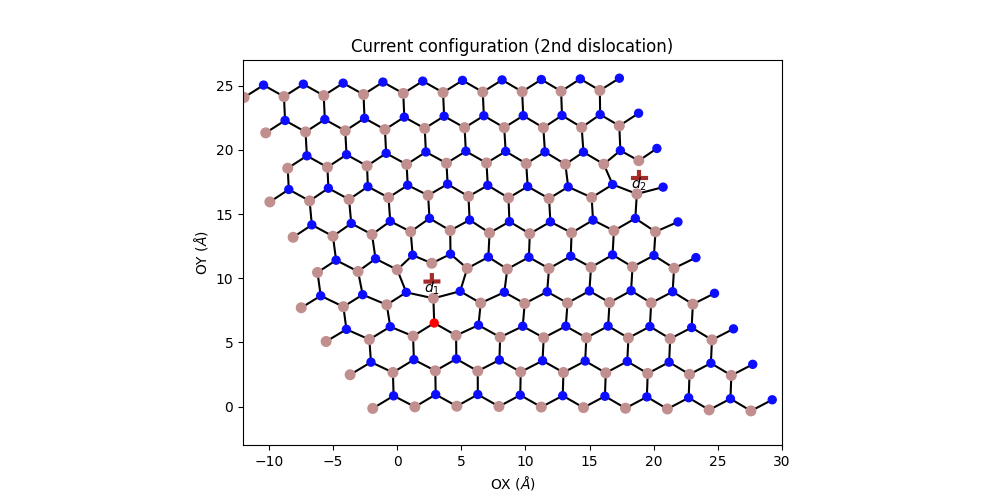

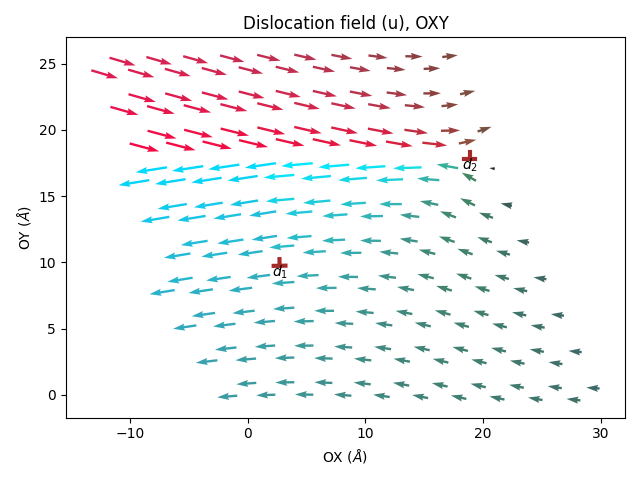

In [21]:
# Przesuń atomy
l2 = l1.translate(u1)
# Zaktualizuj wiązania
l2 = wzt.generate.update_bonds(l2, tolerance=0.55)

# Wyswietl nowa siatke
%matplotlib widget
fig, ax = wzt.visualization.plot_atoms_2d(l2, xlim=(-12, 30), ylim=(-3, 27), figsize=(10, 5), highlighted_atoms={45})
# Wyswietl teownik
wzt.visualization.display_tee_2d(ax, new_d1, scale=0.5)
wzt.visualization.display_tee_2d(ax, d2, scale=0.5)
ax.set_title("Current configuration (2nd dislocation)")
fig, ax = wzt.visualization.plot_displacement(l1, u1)
wzt.visualization.display_tee_2d(ax, new_d1, scale=0.5)
wzt.visualization.display_tee_2d(ax, d2, scale=0.5)

### Druga dyslokacja

<Axes: xlabel='OX ($\\AA$)', ylabel='OY ($\\AA$)'>

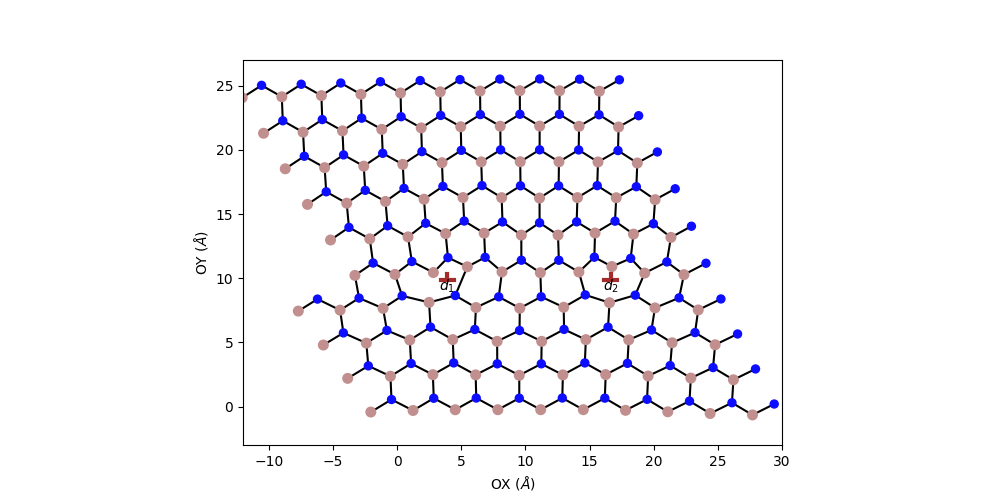

In [22]:
d2 = wzt.model.DislocationDef(
    # Wektor burgersa
    b=[1, 0, 0],
    position= np.asarray(d1.position)+np.array([4.0*l0.cell.dimensions[0], 0.0, 0.0]),
    plane=(0, 0, 1),
    label="$d_2$",
    color="brown"
)

u2, all_us = displace_love2(
    crystal=l1,
    position=d2.position,
    burgers_vector=d2.b,
    plane=d2.plane,
    bv_fraction=1.0,
)


# Przesuń atomy
l2 = l1.translate(u2)
# Zaktualizuj wiązania
l2 = wzt.generate.update_bonds(l2, tolerance=0.6)

# Wyswietl nowa siatke
%matplotlib widget
fig, ax = wzt.visualization.plot_atoms_2d(l2, xlim=(-12, 30), ylim=(-3, 27), figsize=(10, 5),)
# Wyswietl teownik
wzt.visualization.display_tee_2d(ax, d1, scale=0.5)
wzt.visualization.display_tee_2d(ax, d2, scale=0.5)

## Trzecia dyslokacja

<Axes: xlabel='OX ($\\AA$)', ylabel='OY ($\\AA$)'>

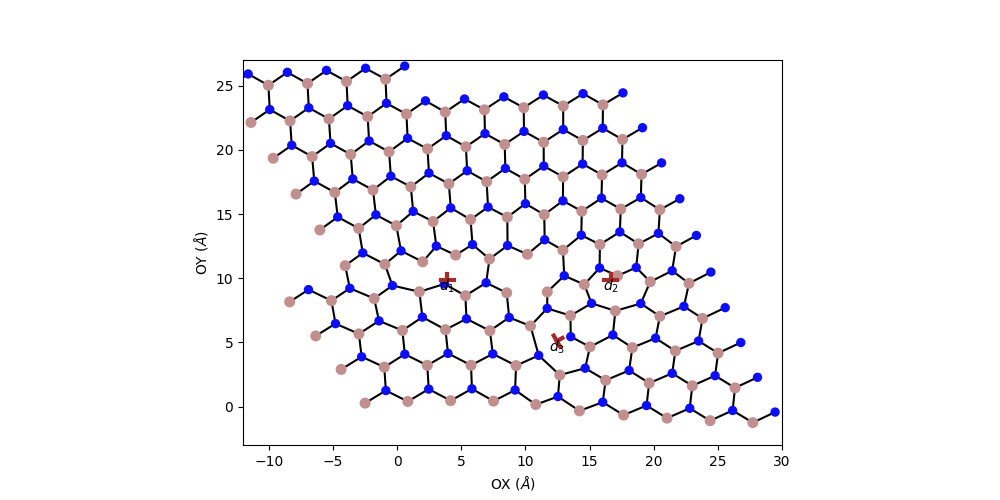

In [23]:

def rotate(v, angle_deg):
    angle = angle_deg/180 * np.pi
    v = np.asarray(v).reshape(-1, 1)[:2]
    rm = np.asarray([[np.cos(angle), -np.sin(angle)],[np.sin(angle), np.cos(angle)]])
    result = np.zeros(3)
    result[:2] = np.dot(rm, v).squeeze()
    return result
    
d3 = wzt.model.DislocationDef(
    # Wektor burgersa 
    b=rotate([1, 0, 0], -90),  # kat w ukladzie wspolrzednych komorki elementarnej (czyli -90 to 120 stopni w komorce elementarnej)
    position= np.asarray(d1.position)+np.array([3.*l0.cell.dimensions[0]-1.0, -1.5*l0.cell.dimensions[1], 0.0]),
    plane=(0, 0, 1),
    label="$d_3$",
    color="brown"
)

# kat powyzszy jest w ukla
d3_display = dataclasses.replace(d3, b=rotate([1, 0, 0], -60))

u3, all_us = displace_love2(
    crystal=l1,
    position=d3.position,
    burgers_vector=d3.b,
    plane=d3.plane,
    bv_fraction=1.0,
)


# Przesuń atomy
l3 = l2.translate(u3)
# Zaktualizuj wiązania
l3 = wzt.generate.update_bonds(l3, tolerance=0.55)

# Wyswietl nowa siatke
%matplotlib widget
fig, ax = wzt.visualization.plot_atoms_2d(l3, xlim=(-12, 30), ylim=(-3, 27), figsize=(10, 5),)
# Wyswietl teownik
wzt.visualization.display_tee_2d(ax, d1, scale=0.5)
wzt.visualization.display_tee_2d(ax, d2, scale=0.5)
wzt.visualization.display_tee_2d(ax, d3_display, scale=0.5)

<Axes: xlabel='OX ($\\AA$)', ylabel='OY ($\\AA$)'>

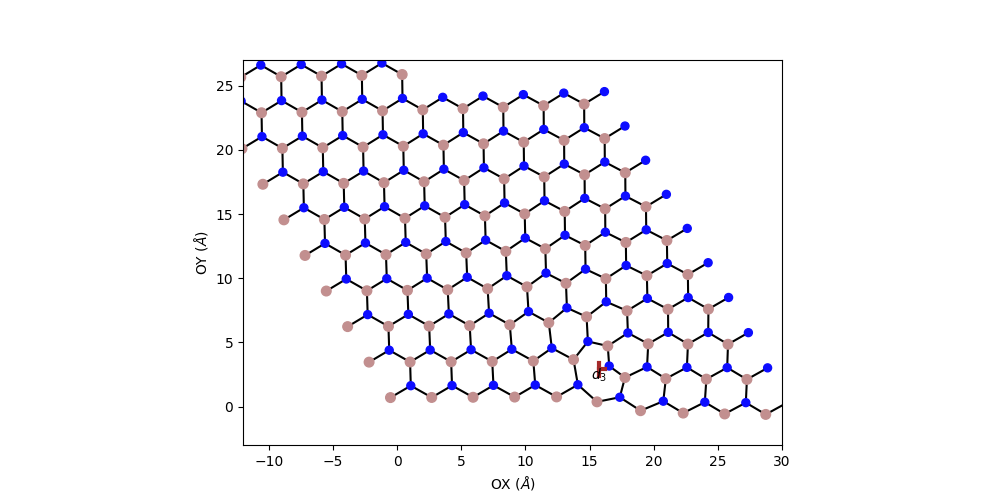

In [24]:
def rotate(v, angle_deg):
    angle = angle_deg/180 * np.pi
    v = np.asarray(v).reshape(-1, 1)[:2]
    rm = np.asarray([[np.cos(angle), -np.sin(angle)],[np.sin(angle), np.cos(angle)]])
    result = np.zeros(3)
    result[:2] = np.dot(rm, v).squeeze()
    return result
    
dd = wzt.model.DislocationDef(
    # Wektor burgersa
    b=rotate([1, 0, 0], -90),
    position= np.asarray(d1.position)+np.array([4.5*l0.cell.dimensions[0]-2.5, -2*l0.cell.dimensions[1]-0.6, 0.0]),
    plane=(0, 0, 1),
    label="$d_3$",
    color="brown"
)

uu = wzt.dislocations.displace_love(
    crystal=l0,
    position=dd.position,
    burgers_vector=dd.b,
    plane=dd.plane,
    bv_fraction=1.0,
    tolerance=1e-2
)


# Przesuń atomy
ll = l0.translate(uu)
# Zaktualizuj wiązania
ll = wzt.generate.update_bonds(ll, tolerance=0.5)

# Wyswietl nowa siatke
%matplotlib widget
fig, ax = wzt.visualization.plot_atoms_2d(ll, xlim=(-12, 30), ylim=(-3, 27), figsize=(10, 5),)
# Wyswietl teownik

wzt.visualization.display_tee_2d(ax, dd, scale=0.5)